In [1]:
import pyvisa
import numpy as np
import time
from abc import ABC, abstractmethod
from typing import Sequence, Optional, Tuple, Any
import matplotlib.pyplot as plt
from function_generator_functions import * 
#Reload the function generator functions to get the latest changes
import importlib

from __future__ import annotations
import scipy.interpolate as interpolate
import h5py as h5
from Oscilloscope import digitizer_base
importlib.reload(digitizer_base)
from Oscilloscope.digitizer_base import Digitizer
scope_module = importlib.import_module("Oscilloscope.Scope")
importlib.reload(scope_module)
from Oscilloscope.Scope import Scope
import matplotlib.pyplot as plt
import os

In [2]:
pattern = "SDG2XFBX801056"
pc_ip = "169.254.102.162"
func_gen = "169.254.102.160"

In [3]:
# offsets = np.linspace(0, -1.8, 100)
# fg.set_square_wave(chn=1, freq=10, amp=1e-2, offset=-1.8)

# fg.set_output(chn=1, enable=True, load='50')


In [ ]:
# # #Turn off output after testing
# fg.set_output(chn=1, enable=False)

In [2]:
#Connect to scope
scope_ip = "169.254.251.130"
if __name__ == "__main__":
    # # 1. Update this with the IP address found on the scope's screen
    # scope_address = f"TCPIP0::{scope_ip}::hislip0::INSTR"

    # # 2. Update this with the IP you set for your Function Generator earlier
    # fg_address = f"TCPIP0::{func_gen}::inst0::INSTR"
    # Function Generator Address
    fg_address = "TCPIP0::192.168.1.10::inst0::INSTR"

    # Scope Address (Revert to inst0)
    scope_address = "TCPIP0::192.168.2.10::inst0::INSTR"

    try:
        # Connect to the Oscilloscope
        print("Connecting to Scope...")
        scope = Scope(visa_address=scope_address)
        
        # Connect to the Function Generator (using your RSDG class from before)
        print("Connecting to Function Generator...")
        fg = RSDG(visa_address=fg_address)


    except Exception as e:
        print(f"Connection failed: {e}")

Connecting to Scope...
Connecting to Function Generator...
Func Gen: connected to: RS, ,SDG2XFBX801056,2.01.01.38



In [3]:
import time

# 1. Clear the hardware-level buffers
scope.DSO.clear() 
time.sleep(1)

# 2. Nuclear Reset: Clear all errors until the queue is empty
print("Clearing error queue...")
for _ in range(10):
    try:
        err = scope.DSO.query(":SYSTem:ERRor?")
        print(f"Cleared: {err}")
        if "No error" in err: break
    except:
        scope.DSO.clear()

# 3. Force the scope back to a "safe" state
scope.DSO.write("*CLS")
scope.DSO.write(":SYSTem:LOCal")
print("Scope is now clean and ready.")

Clearing error queue...
Cleared: +0,"No error"
Scope is now clean and ready.


Starting acquisition...
[0.00000000e+00 1.00806452e-05 2.01612903e-05 3.02419355e-05
 4.03225806e-05 5.04032258e-05 6.04838710e-05 7.05645161e-05
 8.06451613e-05 9.07258065e-05 1.00806452e-04 1.10887097e-04
 1.20967742e-04 1.31048387e-04 1.41129032e-04 1.51209677e-04
 1.61290323e-04 1.71370968e-04 1.81451613e-04 1.91532258e-04
 2.01612903e-04 2.11693548e-04 2.21774194e-04 2.31854839e-04
 2.41935484e-04 2.52016129e-04 2.62096774e-04 2.72177419e-04
 2.82258065e-04 2.92338710e-04 3.02419355e-04 3.12500000e-04
 3.22580645e-04 3.32661290e-04 3.42741935e-04 3.52822581e-04
 3.62903226e-04 3.72983871e-04 3.83064516e-04 3.93145161e-04
 4.03225806e-04 4.13306452e-04 4.23387097e-04 4.33467742e-04
 4.43548387e-04 4.53629032e-04 4.63709677e-04 4.73790323e-04
 4.83870968e-04 4.93951613e-04 5.04032258e-04 5.14112903e-04
 5.24193548e-04 5.34274194e-04 5.44354839e-04 5.54435484e-04
 5.64516129e-04 5.74596774e-04 5.84677419e-04 5.94758065e-04
 6.04838710e-04 6.14919355e-04 6.25000000e-04 6.35080645e-04


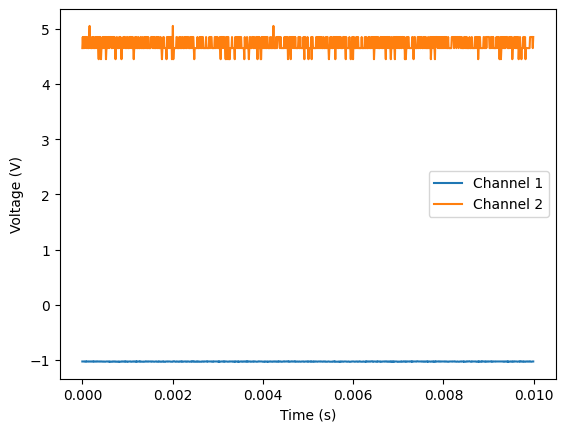

Success!


In [ ]:
# import matplotlib.pyplot as plt

# # 1. Clear Errors and UNLOCK the front panel buttons
# scope.DSO.write("*CLS")
# scope.DSO.write(":SYSTem:LOCal") 

# # 2. Set the Trigger to AUTO so it captures immediately
# scope.DSO.write(":TRIGger:SWEep AUTO")

# # 3. SET DATA POINTS CORRECTLY
# # Use :WAVeform:POINts instead of :ACQuire:POINts
# # We use 'int' to ensure we don't send a decimal (like 100.0)
# scope.DSO.write(":WAVeform:POINts:MODE NORMal") 
# scope.DSO.write(f":WAVeform:POINts {int(1000)}") 

# # 4. Set high timeout for Ethernet transfer
# scope.DSO.timeout = 100000/3  # 100 seconds divided by 3 to be safe
# channels = [1, 2]
# t, y = scope.acquire2(channels=channels)

In [4]:
# photo_detector_data = y[0]  # Assuming channel 1 is the photodetector
# controller_data = y[1]  # Assuming channel 2 is the temperature sensor



def voltage_to_kOhm(voltage):
    r = voltage * 20.44
    return np.asarray(r)
# resist = voltage_to_kOhm(controller_data)
temperature = np.array([
    -40, -35, -30, -25, -20, -15, -10, -5,
      0,   5,  10,  15,  20,  25,  30,  35,
     40,  45,  50,  55,  60,  65,  70,  75,
     80,  85,  90,  95, 100
])
resistance_nominal = np.array([
    2664.0, 1933.0, 1421.0, 1052.0,  788.5,  594.4,  453.0,  347.6,
     269.3,  209.7,  164.8,  130.1,  103.6,   83.00,  66.91,  54.19,
      44.18,  36.17,  29.80,  24.65,  20.51,  17.13,  14.37,  12.10,
      10.24,   8.700,  7.419,  6.351,  5.460
]) #kOhm
fit = interpolate.interp1d(temperature, resistance_nominal, kind='cubic')
temperature_fit = np.linspace(temperature.min(), temperature.max(), 100)
resistance_fit = fit(temperature_fit)
def temperature_from_resistance(res):
    """
    Calculate the temperature corresponding to a given resistance using the cubic spline fit.
    """
    # Create an inverse function for the fit
    inverse_fit = interpolate.interp1d(resistance_fit, temperature_fit, kind='cubic', fill_value="extrapolate")
    return inverse_fit(res)
# temp = temperature_from_resistance(resist)
temperature_from_resistance(12)


array(75.24496571)

In [13]:
temperature_from_resistance(60)

array(32.5688213)

In [5]:
def clear_scope():
    # 1. Clear the hardware-level buffers
    scope.DSO.clear() 
    time.sleep(1)

    # 2. Nuclear Reset: Clear all errors until the queue is empty
    print("Clearing error queue...")
    for _ in range(10):
        try:
            err = scope.DSO.query(":SYSTem:ERRor?")
            print(f"Cleared: {err}")
            if "No error" in err: break
        except:
            scope.DSO.clear()

    # 3. Force the scope back to a "safe" state
    scope.DSO.write("*CLS")
    scope.DSO.write(":SYSTem:LOCal")
    print("Scope is now clean and ready.")

from datetime import datetime
from datetime import timedelta

def measure_scope(channels=[1, 2]):
    try:
        # Standardize settings for every measurement to ensure stability
        scope.DSO.write("*CLS")
        scope.DSO.write(":TRIGger:SWEep AUTO")
        scope.DSO.write(":WAVeform:POINts:MODE NORMal") 
        scope.DSO.write(f":WAVeform:POINts {int(1000)}") 
        
        # Using the acquire2 we fixed earlier
        t, y = scope.acquire2(channels=channels)
        
        # Calculate means for each channel
        # y has shape (num_channels, num_points)
        avgs = [np.mean(ch_data) for ch_data in y]
        #standard deviation
        std = [np.std(ch_data) for ch_data in y]
        return t, y, avgs, std
    except Exception as e:
        print(f"Scope error during measurement: {e}")
        return None, None, None, None

def overnight_measure(total_time=3600, n_measurements=10, channels=[1, 2]):
    clear_scope()
    
    generator_offsets = np.linspace(0, -1.9, n_measurements) # OFFSET
    measurement_interval = total_time / n_measurements
    
    # Create filename with timestamp now so we can save incrementally
    start_time_str = datetime.now().strftime('%d-%m-%Y_%H-%M')
    filename = f"Overnight_data\\Overnight_data_{start_time_str}.csv"
    
    print(f"Starting experiment. Data will be saved to {filename}")
    print(f"Total Time: {total_time}s, Measurements: {n_measurements}, Interval: {measurement_interval:.1f}s")
    print(f"Will be finished at approximately: {(datetime.now() + timedelta(seconds=total_time)).strftime('%H:%M:%S')}")
    
    results = []

    for i in range(n_measurements):
        current_offset = generator_offsets[i]
        print(f"[{i+1}/{n_measurements}] Setting Offset to {current_offset:.3f}V...")
        
        # 1. Set Temperature
        fg.set_square_wave(chn=1, freq=10, amp=1e-2, offset=current_offset)
        fg.set_output(chn=1, enable=True, load='50')
        
        # 2. WAIT for thermal equilibrium BEFORE measuring
        # We wait for the interval BEFORE the measurement
        if i > 0: # Don't wait before the very first one if it's already at start temp
            print(f"Waiting {measurement_interval:.1f}s for thermal settling...")
            time.sleep(measurement_interval)
        
        # 3. Measure
        t_data, y_data, avgs, std = measure_scope(channels=channels)
        # Also calculate the standard error of the mean for each channel
        sem = [std_val / np.sqrt(len(t_data)) for std_val in std]
        if avgs is not None:
            # Store timestamp, offset, and the averages
            timestamp = i * measurement_interval
            row = [timestamp, current_offset] + avgs + std + sem
            results.append(row)
            
            # 4. Incremental Save (Saves data even if it crashes later!)
            header = "Time_s,Offset_V," + ",".join([f"Ch{c}_Avg" for c in channels]) + "," + ",".join([f"Ch{c}_Std" for c in channels]) + "," + ",".join([f"Ch{c}_SEM" for c in channels])
            np.savetxt(filename, np.array(results), delimiter=',', header=header, comments='')
        else:
            print("Measurement failed, attempting to clear scope for next round...")
            clear_scope()

    # Cleanup
    fg.set_output(chn=1, enable=False)
    print(f"Experiment Complete. Final data in {filename}")


In [6]:
test_time = 60 * 15  # 15 minutes for testing
overnight_measure(total_time=test_time, n_measurements=100, channels=[1,3,4])

Clearing error queue...
Cleared: -113,"Undefined header"
Cleared: +0,"No error"
Scope is now clean and ready.
Starting experiment. Data will be saved to Overnight_data\Overnight_data_17-04-2026_08-47.csv
Total Time: 900s, Measurements: 100, Interval: 9.0s
Will be finished at approximately: 09:02:51
[1/100] Setting Offset to 0.000V...
[2/100] Setting Offset to -0.019V...
Waiting 9.0s for thermal settling...
[3/100] Setting Offset to -0.038V...
Waiting 9.0s for thermal settling...
[4/100] Setting Offset to -0.058V...
Waiting 9.0s for thermal settling...
[5/100] Setting Offset to -0.077V...
Waiting 9.0s for thermal settling...
[6/100] Setting Offset to -0.096V...
Waiting 9.0s for thermal settling...
[7/100] Setting Offset to -0.115V...
Waiting 9.0s for thermal settling...
[8/100] Setting Offset to -0.134V...
Waiting 9.0s for thermal settling...
[9/100] Setting Offset to -0.154V...
Waiting 9.0s for thermal settling...
[10/100] Setting Offset to -0.173V...
Waiting 9.0s for thermal settling.

In [6]:
time.sleep(60*30) # Wait 30 minutes before starting to ensure everything is ready
test_time =  60*30 # 30 minutes for testing
for i in range(7):
    overnight_measure(total_time=test_time, n_measurements=300, channels=[1, 2, 3])
    #wait 1.5 hours to cool crystal
    time.sleep(60*90)


Clearing error queue...
Cleared: -113,"Undefined header"
Cleared: +0,"No error"
Scope is now clean and ready.
Starting experiment. Data will be saved to Overnight_data\Overnight_data_16-04-2026_17-23.csv
Total Time: 1800s, Measurements: 300, Interval: 6.0s
Will be finished at approximately: 17:53:49
[1/300] Setting Offset to 0.000V...
Scope error during measurement: VI_ERROR_TMO (-1073807339): Timeout expired before operation completed.


TypeError: 'NoneType' object is not iterable

Max Temperature: 165.18 °C
180


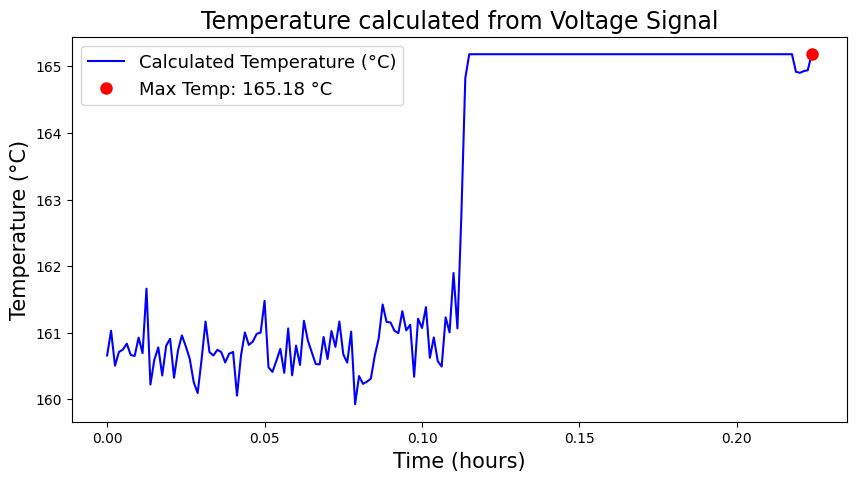

In [12]:
filepath = r"Overnight_data\Overnight_data_14-04-2026_15-38.csv" # Update with your actual filename
data = np.genfromtxt(filepath, delimiter=',', skip_header=1)
time_data = data[:, 0]
time_hours = time_data / 3600
channel1 = data[:, 2]  # Assuming Ch1_Avg is the 3rd column
channel2 = data[:, 3]  # Assuming Ch2_Avg is the 4th column
std = data[:, 4:]  # Standard deviations for each channel

resist = voltage_to_kOhm(channel2)
temperature = temperature_from_resistance(resist)
fig, axs = plt.subplots(1, 1, figsize=(10, 5))

axs.plot(time_hours, temperature, label='Calculated Temperature (°C)', color='blue')
axs.set_title('Temperature calculated from Voltage Signal',fontsize=17)
axs.set_xlabel('Time (hours)',fontsize=15)
axs.set_ylabel('Temperature (°C)',fontsize=15)
#Index for top temperature
max_temp = np.max(temperature)
max_temp_index = np.argmax(temperature)
print(f"Max Temperature: {max_temp:.2f} °C")
axs.plot(time_hours[max_temp_index], max_temp, 'ro', label=f'Max Temp: {max_temp:.2f} °C', markersize=8)
axs.legend(fontsize=13)
print(len(temperature))
#Savefig as pdf
# plt.savefig("C:\\Users\\eskil\\OneDrive\\DTU\\6.sem\\bachelor_project\\figures\\maxtemp.pdf", format="pdf")

First Total time: 5.97 hours, Measurements: 200
Second Total time: 5.97 hours, Measurements: 200


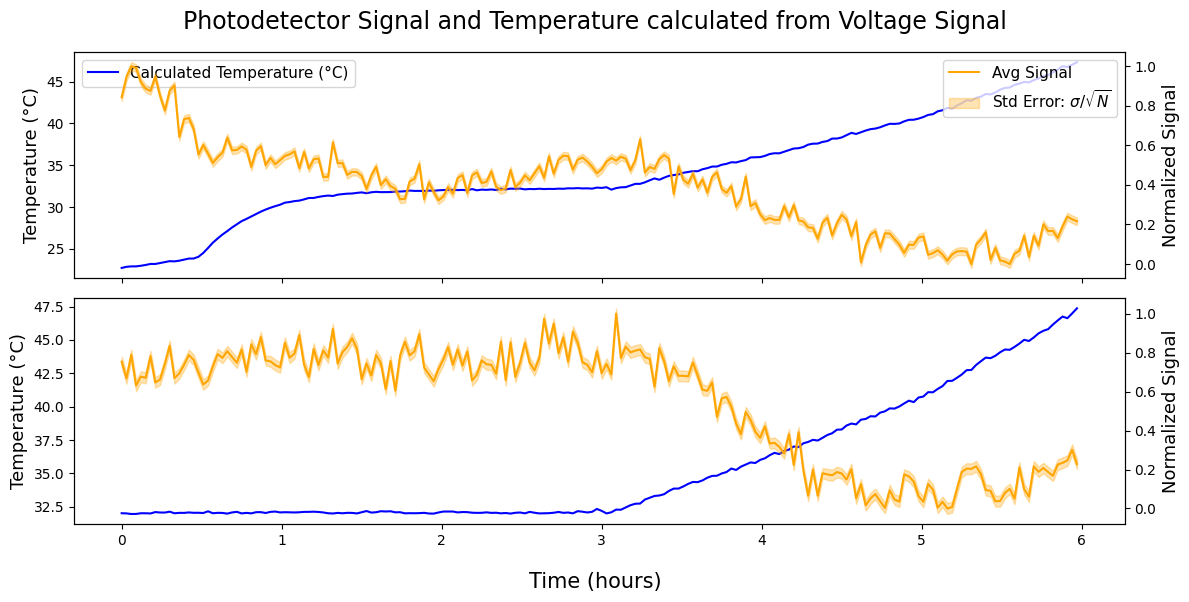

In [ ]:
filepath = r"Overnight_data\Overnight_data_31-03-2026_17-11.csv" # Update with your actual filename
filepath2 = r"Overnight_data\Overnight_data_01-04-2026_00-42.csv" # Update with your actual filename
data = np.genfromtxt(filepath, delimiter=',', skip_header=1)
data2 = np.genfromtxt(filepath2, delimiter=',', skip_header=1)
time_data = data[:, 0]
time_hours = time_data / 3600
time_data2 = data2[:, 0]
time_hours2 = time_data2 / 3600
channel1 = data[:, 2]  # Assuming Ch1_Avg is the 3rd column
channel2 = data[:, 3]  # Assuming Ch2_Avg is the 4th column
std = data[:, 4:]  # Standard deviations for each channel
SEM = data[:, 6:]  # Standard error of the mean for each channel

channel1_2 = data2[:, 2]  # Assuming Ch1_Avg is the 3rd column
channel2_2 = data2[:, 3]  # Assuming Ch2_Avg is
std_2 = data2[:, 4:]  # Standard deviations for each channel
SEM_2 = data2[:, 6:]  # Standard error of the mean for each channel

resist = voltage_to_kOhm(channel2)
temperature = temperature_from_resistance(resist)
fig, (axs, axs22) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

resist_2 = voltage_to_kOhm(channel2_2)
temperature_2 = temperature_from_resistance(resist_2)

# Normalize channel 1
normalized_channel1 = (channel1 - np.min(channel1)) / (np.max(channel1) - np.min(channel1))

# Normalize the standard deviation using the same scaling factor
normalized_std = SEM[:, 0] / (np.max(channel1) - np.min(channel1))

normalized_channel1_2 = (channel1_2 - np.min(channel1_2)) / (np.max(channel1_2) - np.min(channel1_2))
normalized_std_2 = SEM_2[:, 0] / (np.max(channel1_2) - np.min(channel1_2))

# Calculate the shaded region boundaries using the normalized values
normalized_top_shaded = normalized_channel1 + normalized_std
normalized_bottom_shaded = normalized_channel1 - normalized_std

normalized_top_shaded_2 = normalized_channel1_2 + normalized_std_2
normalized_bottom_shaded_2 = normalized_channel1_2 - normalized_std_2

fig.suptitle('Photodetector Signal and Temperature calculated from Voltage Signal', fontsize=17)

axs.plot(time_hours, temperature, label='Calculated Temperature (°C)', color='blue')
axs.set_ylabel('Temperature (°C)', fontsize=13)
axs2 = axs.twinx()

# Plot normalized channel1 data
axs2.plot(time_hours, normalized_channel1, label='Avg Signal', color='orange')
axs2.fill_between(time_hours, normalized_bottom_shaded, normalized_top_shaded, color='orange', alpha=0.3, label='Std Error: $\sigma / \sqrt{N}$')
axs2.set_ylabel('Normalized Signal', fontsize=13)
axs.legend(loc='upper left', fontsize=11)
axs2.legend(loc='upper right', fontsize=11)

axs22.plot(time_hours2, temperature_2, label='Calculated Temperature (°C)', color='blue')
axs22.set_ylabel('Temperature (°C)', fontsize=13)
axs2_2 = axs22.twinx()
axs2_2.plot(time_hours2, normalized_channel1_2, label='Avg Signal', color='orange')
axs2_2.fill_between(time_hours2, normalized_bottom_shaded_2, normalized_top_shaded_2, color='orange', alpha=0.3, label='Std Error: $\sigma / \sqrt{N}$')
axs2_2.set_ylabel('Normalized Signal', fontsize=13)

# Common X-axis label
fig.supxlabel('Time (hours)', fontsize=15)
plt.tight_layout()

print('First Total time: {:.2f} hours, Measurements: {}'.format(time_hours[-1], len(time_data)))
print('Second Total time: {:.2f} hours, Measurements: {}'.format(time_hours2[-1], len(time_data2)))
# plt.savefig("C:\\Users\\eskil\\OneDrive\\DTU\\6.sem\\bachelor_project\\figures\\old_crystal-31-03-2026_17-11.pdf", format="pdf", dpi=300)


First Total time: 0.25 hours, Measurements: 100


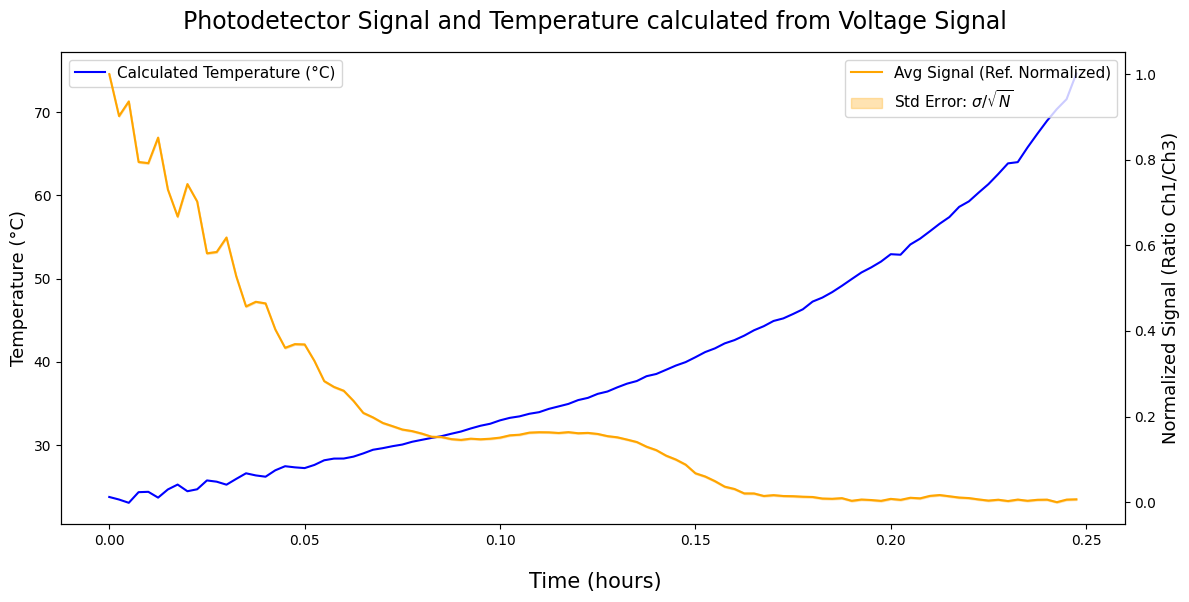

In [7]:
filepath = r"Overnight_data\Overnight_data_17-04-2026_08-47.csv" # Update with your actual filename
data = np.genfromtxt(filepath, delimiter=',', skip_header=1)
time_data = data[:, 0]
time_hours = time_data / 3600
channel1 = data[:, 2]  # Assuming Ch1_Avg is the 3rd column
channel2 = data[:, 3]  # Assuming Ch2_Avg is the 4th column
channel3 = data[:, 4]  # Assuming Ch3_Avg is the 5th column
std = data[:, 5:8]  # Standard deviations for each channel
SEM = data[:, 8:]  # Standard error of the mean for each channel

resist = voltage_to_kOhm(channel2)
temperature = temperature_from_resistance(resist)
fig, axs = plt.subplots(figsize=(12, 6))

# Normalize channel 1 by using channel 3 as reference
# Ratio between active signal and reference
ch1_ch3_ratio = channel1 / channel3

# Calculate ratio SEM using error propagation: err_R = R * sqrt((err_A / A)^2 + (err_B / B)^2)
SEM_ch1 = SEM[:, 0]
SEM_ch3 = SEM[:, 2]
ratio_sem = ch1_ch3_ratio * np.sqrt((SEM_ch1 / channel1)**2 + (SEM_ch3 / channel3)**2)

# Scale the ratio to between 0 and 1
normalized_ratio = (ch1_ch3_ratio - np.min(ch1_ch3_ratio)) / (np.max(ch1_ch3_ratio) - np.min(ch1_ch3_ratio))

# Normalize the propagated standard error of the mean using the same scaling factor
normalized_sem = ratio_sem / (np.max(ch1_ch3_ratio) - np.min(ch1_ch3_ratio))

# Calculate the shaded region boundaries
normalized_top_shaded = normalized_ratio + normalized_sem
normalized_bottom_shaded = normalized_ratio - normalized_sem

fig.suptitle('Photodetector Signal and Temperature calculated from Voltage Signal', fontsize=17)

axs.plot(time_hours, temperature, label='Calculated Temperature (°C)', color='blue')
axs.set_ylabel('Temperature (°C)', fontsize=13)
axs2 = axs.twinx()

# Plot normalized ratio data
axs2.plot(time_hours, normalized_ratio, label='Avg Signal (Ref. Normalized)', color='orange')
axs2.fill_between(time_hours, normalized_bottom_shaded, normalized_top_shaded, color='orange', alpha=0.3, label='Std Error: $\sigma / \sqrt{N}$')
axs2.set_ylabel('Normalized Signal (Ratio Ch1/Ch3)', fontsize=13)
axs.legend(loc='upper left', fontsize=11)
axs2.legend(loc='upper right', fontsize=11)

# Common X-axis label
fig.supxlabel('Time (hours)', fontsize=15)
plt.tight_layout()

print('First Total time: {:.2f} hours, Measurements: {}'.format(time_hours[-1], len(time_data)))
# plt.savefig("C:\\Users\\eskil\\OneDrive\\DTU\\6.sem\\bachelor_project\\figures\\old_crystal-31-03-2026_17-11.pdf", format="pdf", dpi=300)

Total time: 0.50 hours, Measurements: 300
Total time: 0.50 hours, Measurements: 300
Total time: 0.50 hours, Measurements: 300
Total time: 0.50 hours, Measurements: 300
Total time: 0.50 hours, Measurements: 300
Total time: 0.50 hours, Measurements: 300
Total time: 0.50 hours, Measurements: 300
Total time: 0.50 hours, Measurements: 300


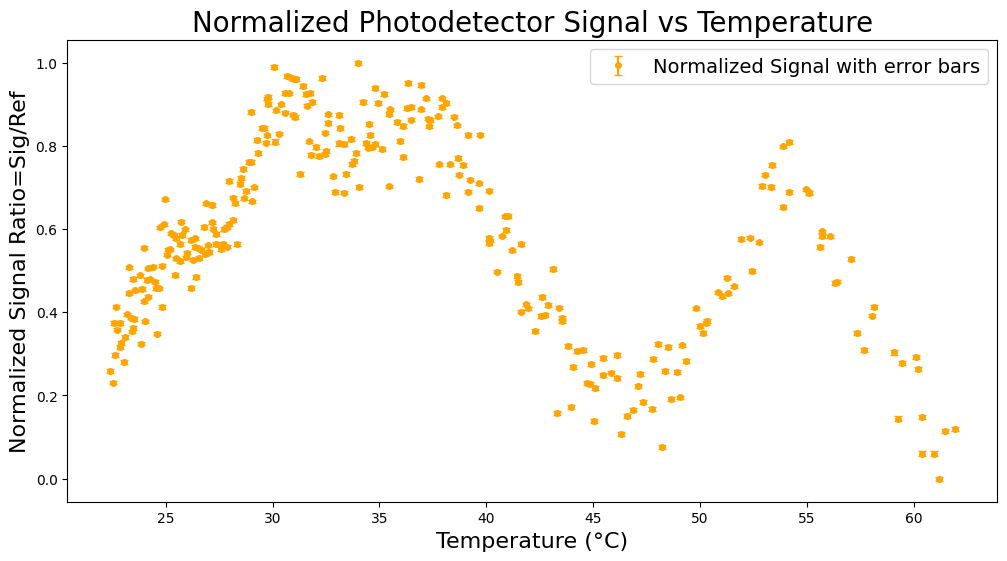

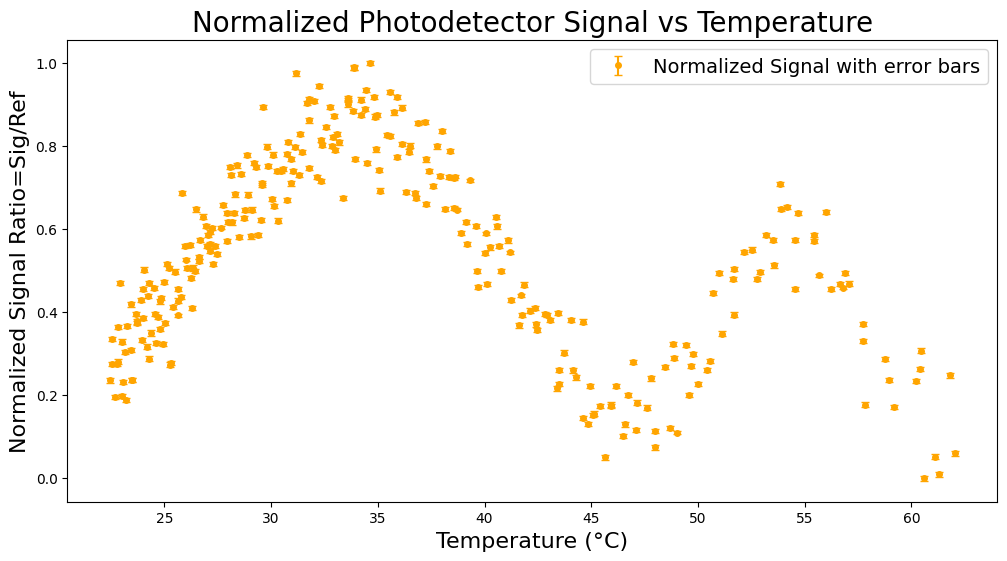

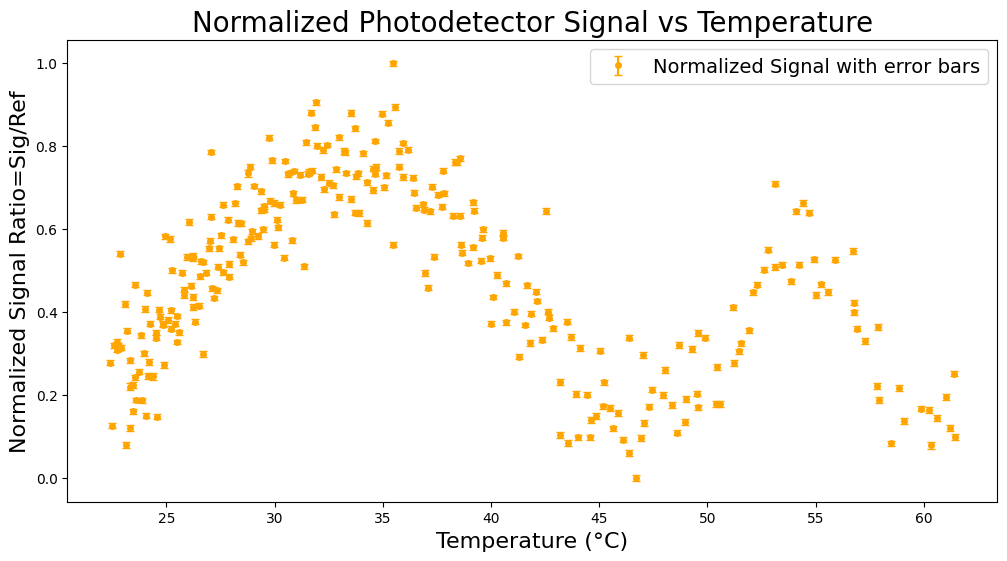

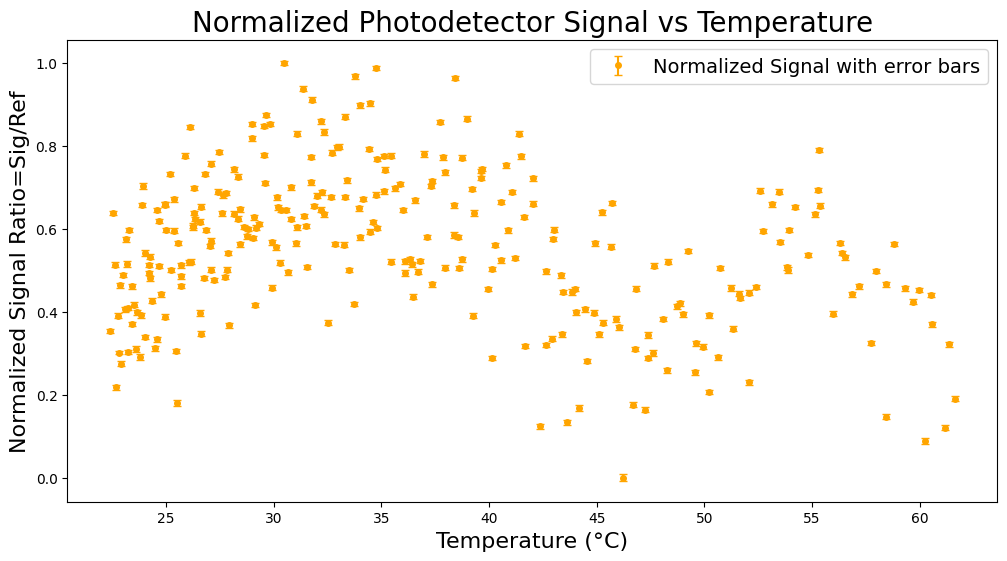

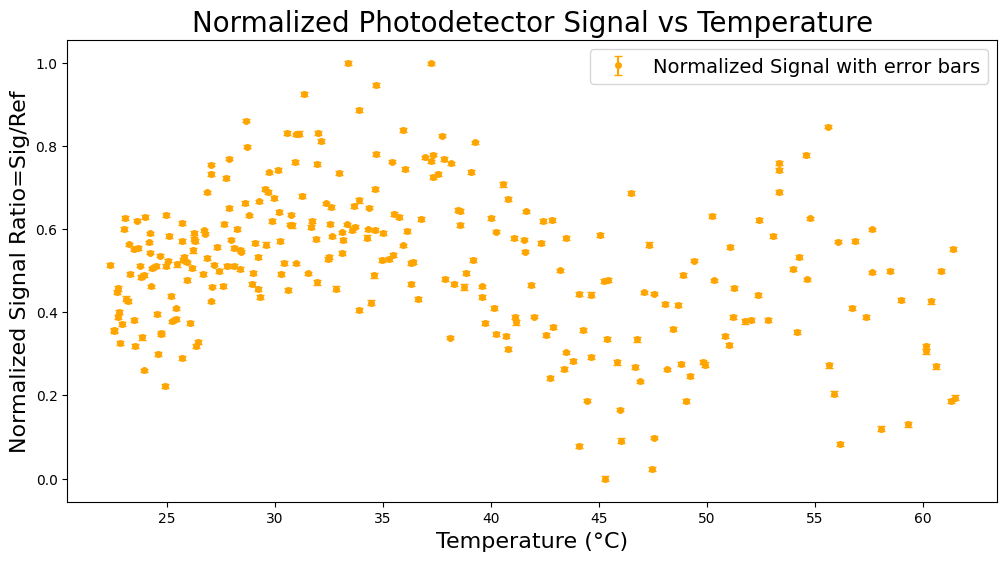

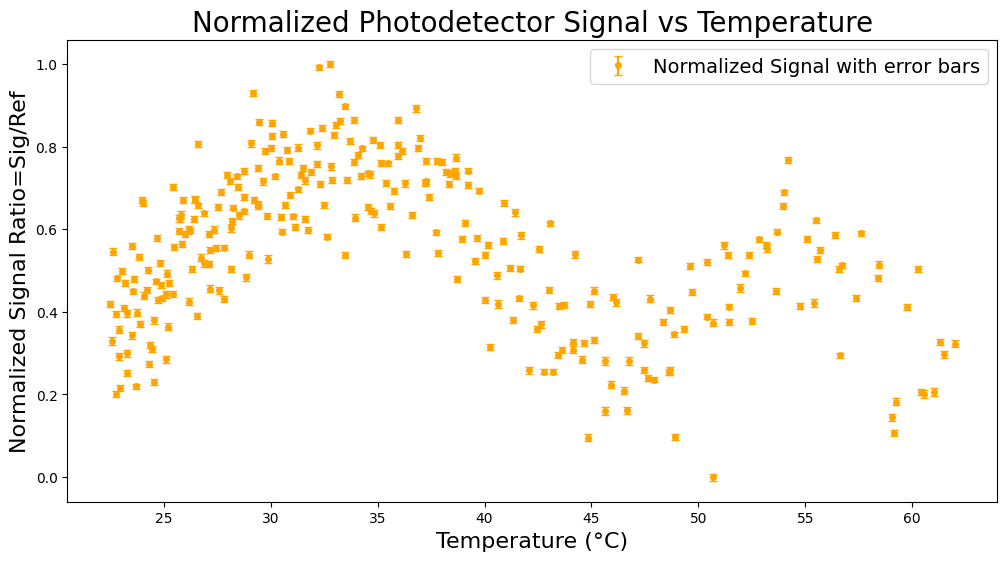

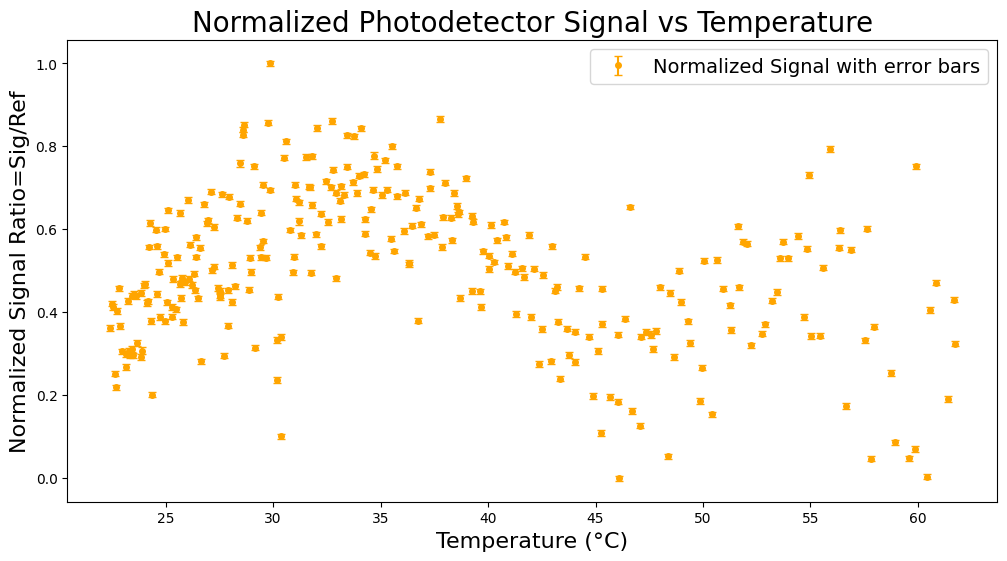

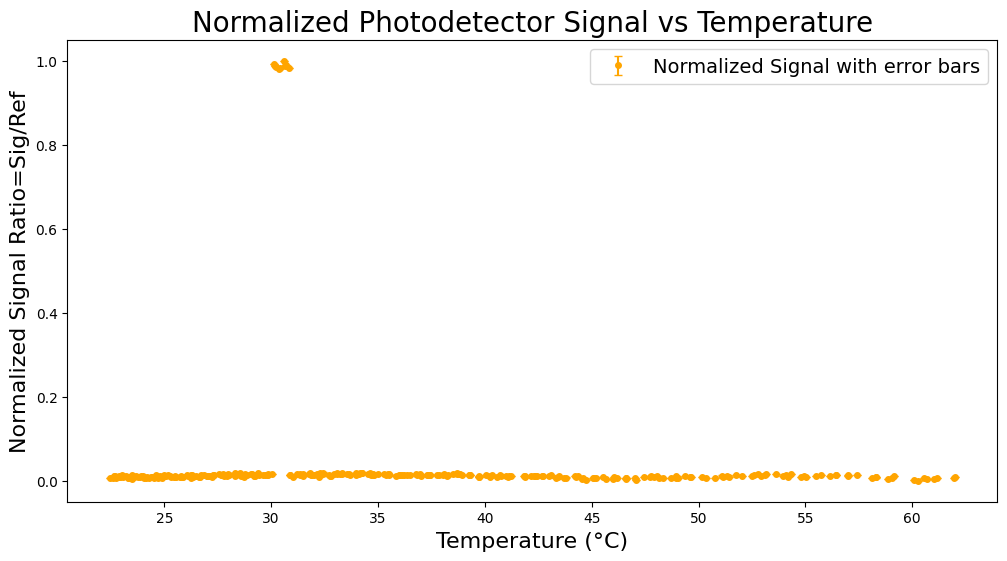

In [19]:
filenames = [r"Overnight_data\Overnight_data_13-04-2026_16-59.csv",
             r"Overnight_data\Overnight_data_13-04-2026_19-05.csv",
             r"Overnight_data\Overnight_data_13-04-2026_21-12.csv",
             r"Overnight_data\Overnight_data_13-04-2026_23-18.csv",
             r"Overnight_data\Overnight_data_14-04-2026_01-25.csv",
             r"Overnight_data\Overnight_data_14-04-2026_03-31.csv",
             r"Overnight_data\Overnight_data_14-04-2026_05-37.csv",
             r"Overnight_data\Overnight_data_14-04-2026_07-44.csv"]
for filepath in filenames:
    data = np.genfromtxt(filepath, delimiter=',', skip_header=1)
    time_data = data[:, 0]
    time_hours = time_data / 3600
    channel1 = data[:, 2]  # Assuming Ch1_Avg is the 3rd column
    channel2 = data[:, 3]  # Assuming Ch2_Avg is the 4th column
    channel3 = data[:, 4]  # Assuming Ch3_Avg is the 5th column
    std = data[:, 5:8]  # Standard deviations for each channel
    SEM = data[:, 8:]  # Standard error of the mean for each channel

    resist = voltage_to_kOhm(channel2)
    temperature = temperature_from_resistance(resist)

    # Normalize channel 1 by using channel 3 as reference
    ch1_ch3_ratio = channel1 / channel3

    SEM_ch1 = SEM[:, 0]
    SEM_ch3 = SEM[:, 2]
    # Ensure error is always positive using np.abs
    ratio_sem = np.abs(ch1_ch3_ratio) * np.sqrt((SEM_ch1 / channel1)**2 + (SEM_ch3 / channel3)**2)

    normalized_ratio = (ch1_ch3_ratio - np.min(ch1_ch3_ratio)) / (np.max(ch1_ch3_ratio) - np.min(ch1_ch3_ratio))
    normalized_sem = ratio_sem / (np.max(ch1_ch3_ratio) - np.min(ch1_ch3_ratio))

    #Normalized signal against temperature
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.errorbar(temperature, normalized_ratio, yerr=normalized_sem, label='Normalized Signal with error bars', color='orange', fmt='o', markersize=4, capsize=3)
    ax.set_xlabel('Temperature (°C)', fontsize=16)
    ax.set_ylabel('Normalized Signal Ratio=Sig/Ref', fontsize=16)
    ax.legend(loc='upper right', fontsize=14)
    ax.set_title('Normalized Photodetector Signal vs Temperature', fontsize=20)
    print(f"Total time: {time_hours[-1]:.2f} hours, Measurements: {len(time_data)}")

1356.6
Total time: 0.50 hours, Measurements: 300
Average raw voltage: 4.09 mV, Average corrected voltage: 4.06 mV, Average power: 2.99 μW
1356.6
Total time: 0.50 hours, Measurements: 300
Average raw voltage: 2.62 mV, Average corrected voltage: 2.62 mV, Average power: 1.93 μW
1356.6
Total time: 0.50 hours, Measurements: 300
Average raw voltage: 0.78 mV, Average corrected voltage: 0.76 mV, Average power: 0.56 μW
1356.6
Total time: 0.50 hours, Measurements: 300
Average raw voltage: 0.08 mV, Average corrected voltage: 0.08 mV, Average power: 0.06 μW
1356.6
Total time: 0.50 hours, Measurements: 300
Average raw voltage: -0.75 mV, Average corrected voltage: -0.75 mV, Average power: -0.55 μW
1356.6
Total time: 0.50 hours, Measurements: 300
Average raw voltage: -0.76 mV, Average corrected voltage: -0.76 mV, Average power: -0.56 μW
1356.6
Total time: 0.50 hours, Measurements: 300
Average raw voltage: -0.92 mV, Average corrected voltage: -0.92 mV, Average power: -0.68 μW
1356.6
Total time: 0.50 h

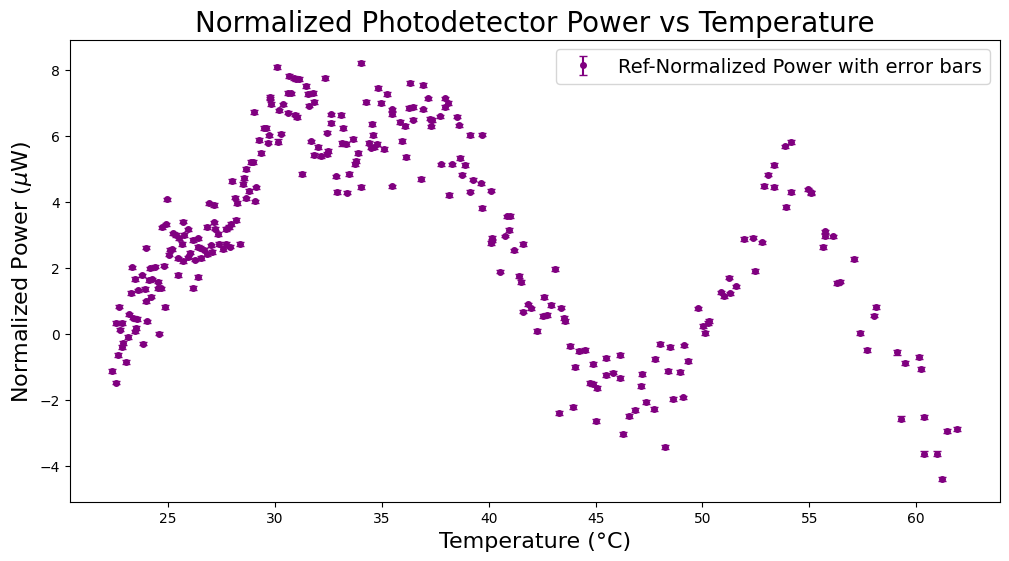

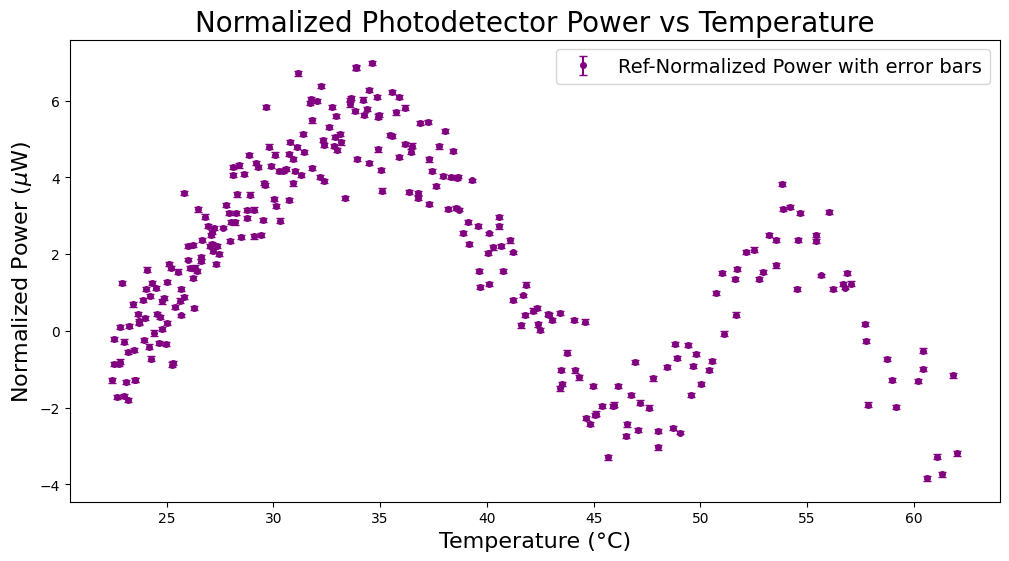

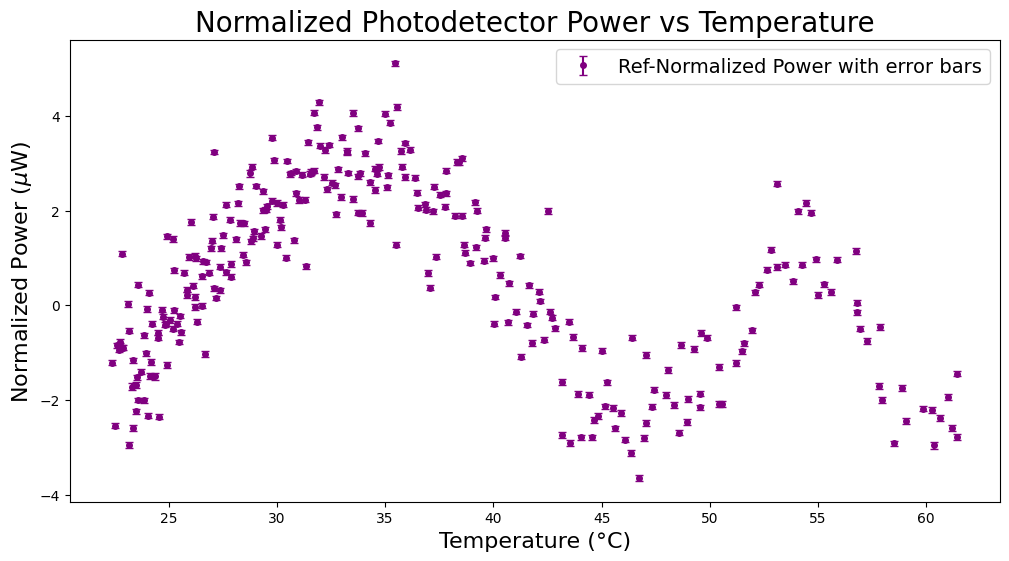

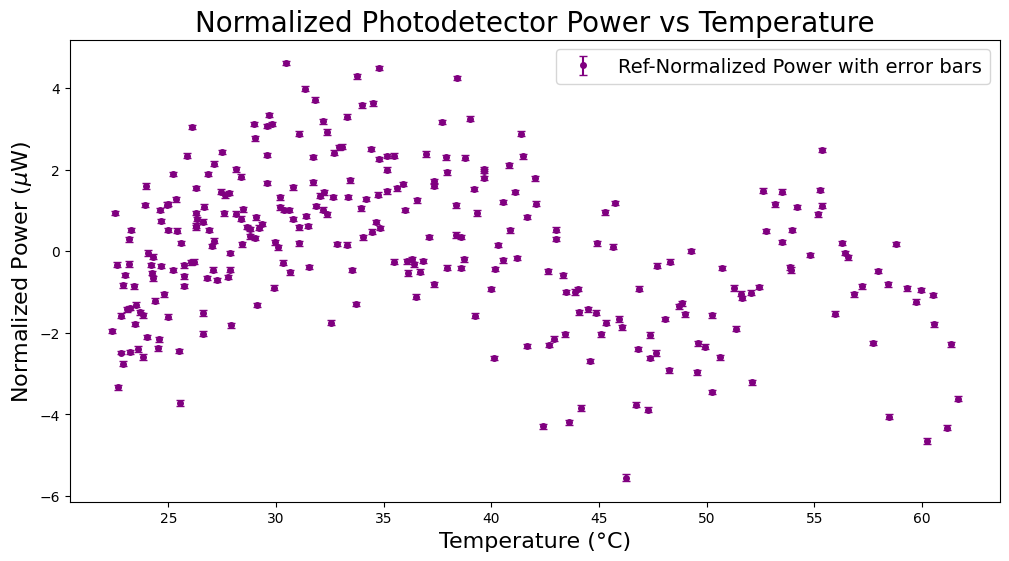

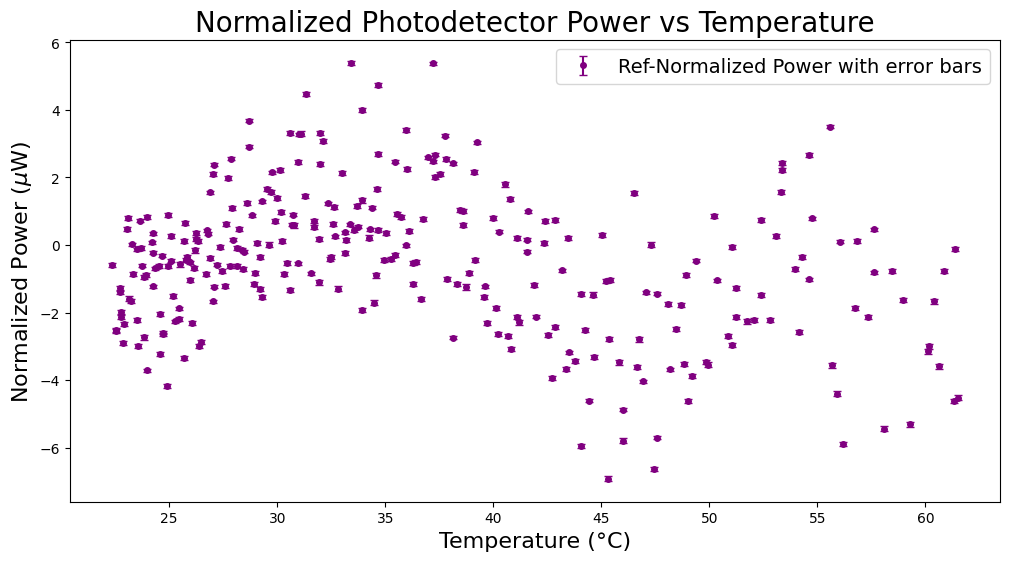

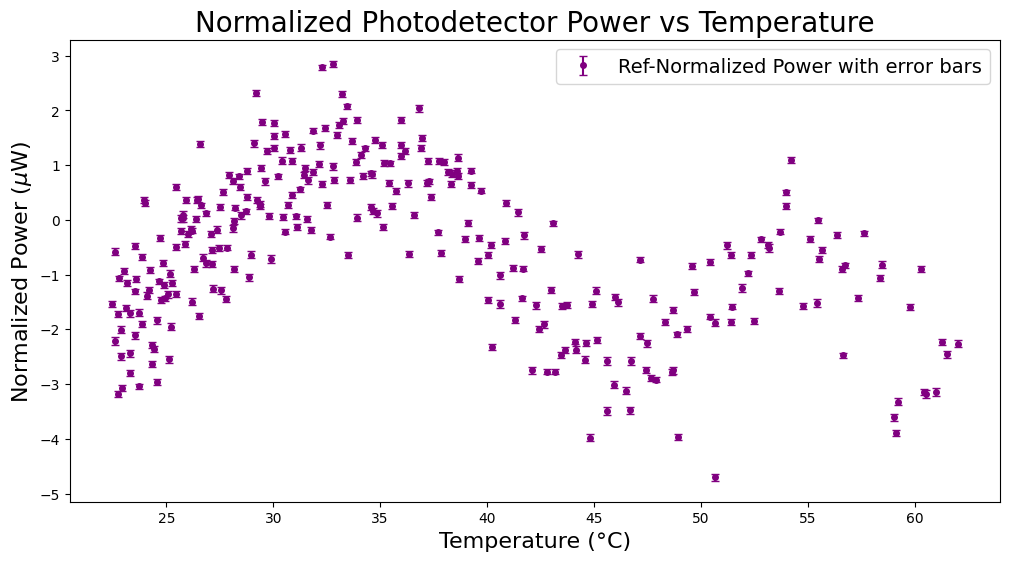

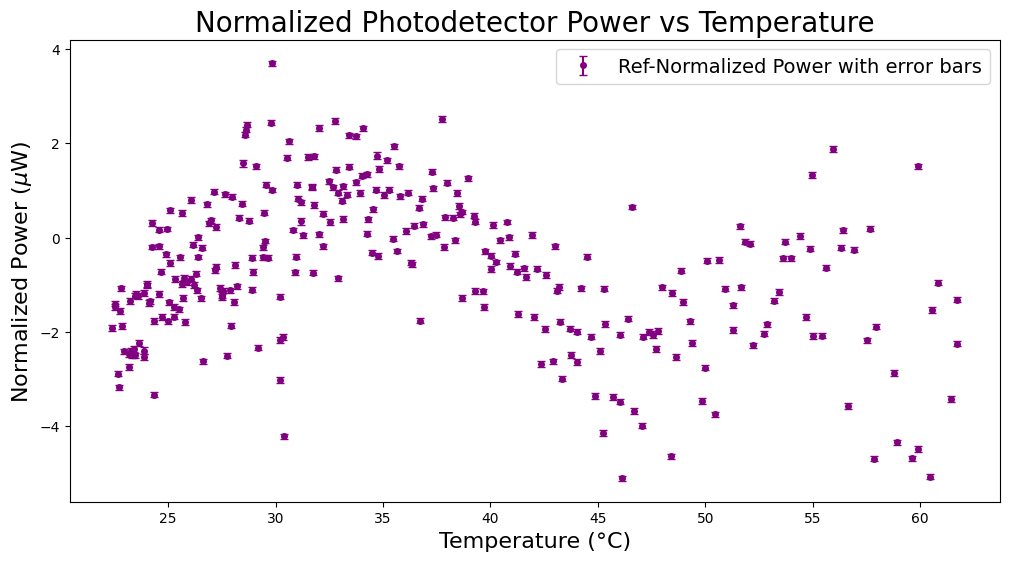

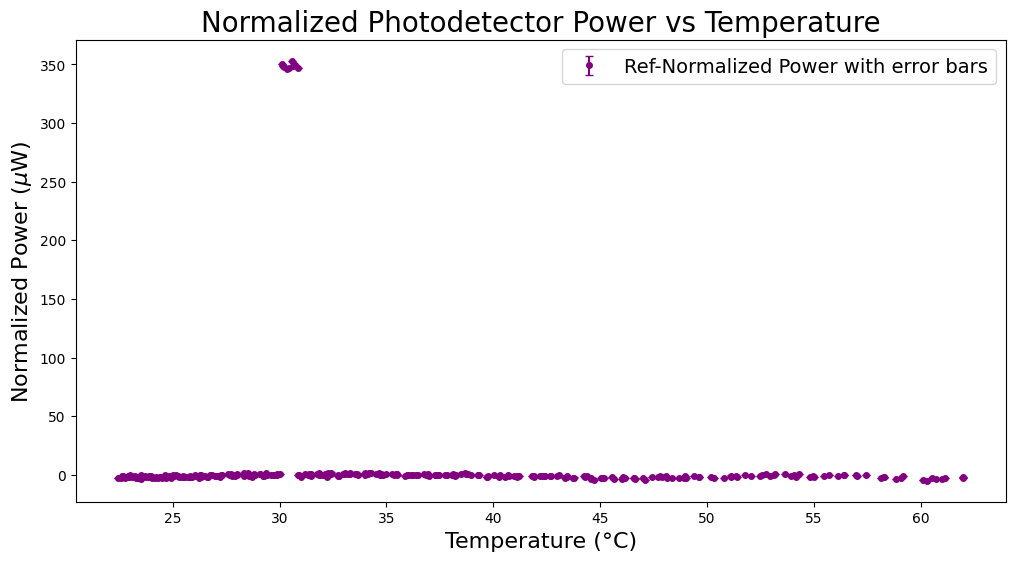

In [20]:
filenames = [r"Overnight_data\Overnight_data_13-04-2026_16-59.csv",
             r"Overnight_data\Overnight_data_13-04-2026_19-05.csv",
             r"Overnight_data\Overnight_data_13-04-2026_21-12.csv",
             r"Overnight_data\Overnight_data_13-04-2026_23-18.csv",
             r"Overnight_data\Overnight_data_14-04-2026_01-25.csv",
             r"Overnight_data\Overnight_data_14-04-2026_03-31.csv",
             r"Overnight_data\Overnight_data_14-04-2026_05-37.csv",
             r"Overnight_data\Overnight_data_14-04-2026_07-44.csv"]

# TODO: Update this value with your detector's actual sensitivity (in V/W) at the used wavelength!
# Example: If sensitivity is 1.5 * 10^5 V/W, use 1.5e5
sensitivity_V_per_W = 0.57 * 2.38e3



for filepath in filenames:
    data = np.genfromtxt(filepath, delimiter=',', skip_header=1)
    time_data = data[:, 0]
    time_hours = time_data / 3600
    channel1 = data[:, 2]  # Assuming Ch1_Avg is the 3rd column
    channel2 = data[:, 3]  # Assuming Ch2_Avg is the 4th column
    channel3 = data[:, 4]  # Assuming Ch3_Avg is the 5th column
    std = data[:, 5:8]  # Standard deviations for each channel
    SEM = data[:, 8:]  # Standard error of the mean for each channel

    resist = voltage_to_kOhm(channel2)
    temperature = temperature_from_resistance(resist)

    # Normalize channel 1 by using channel 3 as reference
    ch1_ch3_ratio = channel1 / channel3
    
    # Scale ratio back to physical voltage by multiplying by the mean reference voltage.
    # This corrects for intensity fluctuations while keeping the absolute scale intact.
    corrected_voltage = ch1_ch3_ratio * np.mean(channel3)

    # Convert corrected voltage to Power in microwatts
    power_W = corrected_voltage / sensitivity_V_per_W
    power_uW = power_W * 1e6  # Convert to microwatts
    
    SEM_ch1 = SEM[:, 0]
    SEM_ch3 = SEM[:, 2]
    # Ensure error is always positive using np.abs
    ratio_sem = np.abs(ch1_ch3_ratio) * np.sqrt((SEM_ch1 / channel1)**2 + (SEM_ch3 / channel3)**2)

    # Convert propagated ratio error to microwatts using the same scaling
    SEM_power_uW = (ratio_sem * np.mean(channel3) / sensitivity_V_per_W) * 1e6
    print(sensitivity_V_per_W)
    # Plot Signal Power vs Temperature
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.errorbar(temperature, power_uW, yerr=SEM_power_uW, label='Ref-Normalized Power with error bars', color='purple', fmt='o', markersize=4, capsize=3)
    ax.set_xlabel('Temperature (°C)', fontsize=16)
    ax.set_ylabel('Normalized Power ($\mu$W)', fontsize=16)
    ax.legend(loc='upper right', fontsize=14)
    ax.set_title('Normalized Photodetector Power vs Temperature', fontsize=20)
    print(f"Total time: {time_hours[-1]:.2f} hours, Measurements: {len(time_data)}")
    print("Average raw voltage: {:.2f} mV, Average corrected voltage: {:.2f} mV, Average power: {:.2f} μW".format(np.mean(channel1)*1e3, np.mean(corrected_voltage)*1e3, np.mean(power_uW)))

In [ ]:
test_time = 60*10 # 60 minutes for testing
n = 7
overnight_measure(total_time=test_time, n_measurements=n, channels=[1, 2])

Clearing error queue...
Cleared: -113,"Undefined header"
Cleared: +0,"No error"
Scope is now clean and ready.
Starting experiment. Data will be saved to Overnight_data\Overnight_data_31-03-2026_14-24.csv
Total Time: 600s, Measurements: 7, Interval: 85.7s
Will be finished at approximately: 14:34:25
[1/7] Setting Offset to 0.000V...
[2/7] Setting Offset to -0.250V...
Waiting 85.7s for thermal settling...
[3/7] Setting Offset to -0.500V...
Waiting 85.7s for thermal settling...
[4/7] Setting Offset to -0.750V...
Waiting 85.7s for thermal settling...
[5/7] Setting Offset to -1.000V...
Waiting 85.7s for thermal settling...
[6/7] Setting Offset to -1.250V...
Waiting 85.7s for thermal settling...
[7/7] Setting Offset to -1.500V...
Waiting 85.7s for thermal settling...
Experiment Complete. Final data in Overnight_data\Overnight_data_31-03-2026_14-24.csv


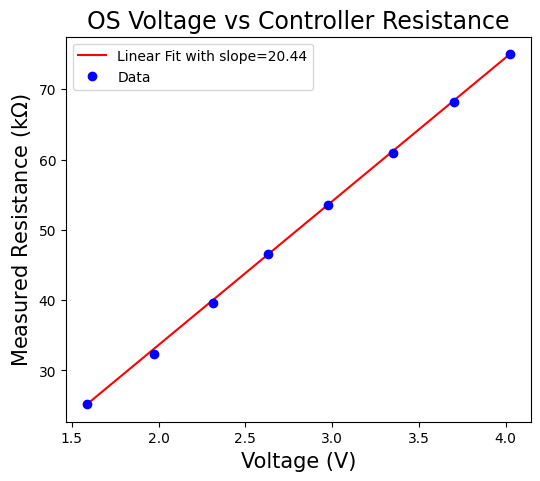

In [ ]:
set_point = [75,68.14,60.9,53.6,46.6,39.6,32.3,25.2]
filepath = 'Overnight_data\Overnight_data_30-03-2026_13-53.csv'
data = np.genfromtxt(filepath, delimiter=',', skip_header=1)
time_data = data[:, 0]
channel1 = data[:, 2]  # Assuming Ch1_Avg is the 3rd column
channel2 = data[:, 3]  # Assuming Ch2_Avg is the 4th column
chan = channel2[2:]
#fit of set vs resistance
fit = interpolate.interp1d(chan, set_point, kind='cubic', fill_value="extrapolate")
xfit = np.linspace(min(chan), max(chan), 100)
yfit = fit(xfit)
slope = (yfit[-1] - yfit[0]) / (xfit[-1] - xfit[0])
intercept = yfit[0] - slope * xfit[0]
yfit_linear = slope * xfit + intercept
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(xfit, yfit_linear, label='Linear Fit with slope={:.2f}'.format(slope), color='red', linestyle='-')
ax.plot(chan, set_point, label='Data', color = 'blue', marker='o', linestyle='None')
ax.set_ylabel('Measured Resistance (k$\Omega$)',fontsize=15)
ax.set_xlabel('Voltage (V)',fontsize=15)
ax.set_title('OS Voltage vs Controller Resistance',fontsize=17)
ax.legend()
plt.show()


In [ ]:
print(chan)

[4.02361938 3.70387553 3.35333254 2.97401665 2.62793143 2.31102435
 1.97365205 1.58724425]
